# Assignment 2: Retrieval-Augmented Generation Question Answering

Welcome to the second assignment for 50.055 Machine Learning Operations This is a continuation of your work in assignment 1, where you will be working to build a chatbot which can answer questions about SUTD to prospective students.


**This assignment is a individual assignment.**

- Read the instructions in this notebook carefully
- Add your solution code and answers in the appropriate places. The questions are marked as **QUESTION:**, the places where you need to add your code and text answers are marked as **ADD YOUR SOLUTION HERE**
- The completed notebook, including your added code and generated output will be your submission for the assignment.
- The notebook should execute without errors from start to finish when you select "Restart Kernel and Run All Cells..". Please test this before submission.
- Use the SUTD Education Cluster to solve and test the assignment. If you work on another environment, minimally test your work on the SUTD Education Cluster.

**Rubric for assessment** 

Your submission will be graded using the following criteria. 
1. Code executes: your code should execute without errors. The SUTD Education cluster should be used to ensure the same execution environment.
2. Correctness: the code should produce the correct result or the text answer should state the factual correct answer.
3. Style: your code should be written in a way that is clean and efficient. Your text answers should be relevant, concise and easy to understand.
4. Partial marks will be awarded for partially correct solutions.
5. Creativity and innovation: in this assignment you have more freedom to design your solution, compared to the first assignments. You can show of your creativity and innovative mindset. 
6. There is a maximum of 215 points for this assignment, which will be normalized to 10% of your grade.

**ChatGPT policy** 

If you use AI tools, such as ChatGPT, Claude, Gemini, etc. to solve the assignment questions, you need to be transparent about its use and mark AI-generated content as such. In particular, you should include the following in addition to your final answer:
- A copy or screenshot of the prompt you used
- The name of the AI model
- The AI generated output
- An explanation why the answer is correct or what you had to change to arrive at the correct answer

**Assignment Notes:** Please make sure to save the notebook as you go along. Submission instructions are located at the bottom of the notebook.



### Retrieval-Augmented Generation (RAG) 

In this assignment, you will be building a Retrieval-Augmented Generation (RAG) question answering system which can answer questions about SUTD.

We'll be leveraging `langchain` and the LLM API of your choice from assignment 1

Check out the docs:
- [LangChain](https://docs.langchain.com/docs/)


The SUTD website used to allow chatting with current students. Unfortunately, this feature does not exist anymore. Let's build a chatbot to fill this gap!


# Install dependencies
Use pip to install all required dependencies of this assignment in the cell below. Make sure to test this on the SUTD cluster as different environments have different software pre-installed.  

In [12]:
# QUESTION: Install and import all required packages
# The rest of your code should execute without any import or dependency errors.

# **--- ADD YOUR SOLUTION HERE (10 points) ---**

import os
os.environ["USER_AGENT"] = "sutd-bot"

import bs4
from dotenv import load_dotenv
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import Chroma
from langchain_anthropic import ChatAnthropic
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents.stuff import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Load environment variables (Make sure ANTHROPIC_API_KEY is in your .env)
load_dotenv()
print("Libraries imported and environment loaded successfully.")
# ----------------


Libraries imported and environment loaded successfully.


# Download documents
The RAG application should be able to answer questions based on ingested documents. For the SUTD chatbot, download PDF and HTML files from the SUTD website. The documents should contain information about the admission process, available courses and the university in general.


In [15]:
# QUESTION: Download documents from the SUTD website
# You should download at least 10 documents but more documents can increase the knowledge base of your chatbot.

# **--- ADD YOUR SOLUTION HERE (20 points) ---**
# Include the URLs from Assignment 1 and add a few more to meet the >=10 requirement.
html_urls = [
    "https://www.sutd.edu.sg/admissions/undergraduate",
    "https://www.sutd.edu.sg/admissions/graduate/masters",
    "https://www.sutd.edu.sg/admissions/graduate/phd",
    "https://www.sutd.edu.sg/research/research-centres",
    "https://www.sutd.edu.sg/education/undergraduate/courses",
    "https://www.sutd.edu.sg/campus-life",
    "https://www.sutd.edu.sg/about/design-ai/",
    "https://www.sutd.edu.sg/about/people/faculty",
    "https://www.sutd.edu.sg/campus-life/housing",
    "https://www.sutd.edu.sg/admissions/undergraduate/financing-options-and-aid",
    "https://www.sutd.edu.sg/education/undergraduate/academic-calendar/overview/ay2024-onwards/",
    "https://www.sutd.edu.sg/education/undergraduate/academic-calendar/overview/ay2020-to-ay2023/"
]

web_loader = WebBaseLoader(web_paths=html_urls, verify_ssl=False)
html_documents = web_loader.load()

pdf_urls = [
    "https://www.sutd.edu.sg/wp-content/uploads/2026/02/SUTD.pdf",
    "https://www.sutd.edu.sg/wp-content/uploads/2025/10/SUTD-Annual-Report-2024-25.pdf"
]

pdf_documents = []
for url in pdf_urls:
    pdf_loader = PyPDFLoader(url)
    # .load() returns a list of pages, so we use .extend() to add them to our master list
    pdf_documents.extend(pdf_loader.load())

documents = html_documents + pdf_documents
print(f"Successfully loaded {len(html_documents)} HTML pages and {len(pdf_documents)} PDF pages.")


Successfully loaded 12 HTML pages and 58 PDF pages.


In [16]:
import os
import json

# Ensure the data folder exists
os.makedirs("data", exist_ok=True)
save_path = "data/sutd_documents_v2.json"

# Extract the text and metadata from your in-memory LangChain Document objects
docs_to_save = [{"page_content": doc.page_content, "metadata": doc.metadata} for doc in documents]

# Save them to a JSON file
with open(save_path, "w", encoding="utf-8") as f:
    json.dump(docs_to_save, f, ensure_ascii=False, indent=4)
    
print(f"✅ Successfully saved {len(documents)} documents to {save_path}!")

✅ Successfully saved 70 documents to data/sutd_documents_v2.json!


In [17]:
import re
for doc in documents:
    raw_text = doc.page_content
    
    # Replace all sequences of whitespace (newlines, tabs, multiple spaces) with a single space
    clean_text = re.sub(r'\s+', ' ', raw_text)
    
    # Strip any leading or trailing spaces, then overwrite the document's content
    doc.page_content = clean_text.strip()

print("Documents successfully cleaned!")

Documents successfully cleaned!


# Split documents
Use LangChain to split the documents into smaller text chunks. 

In [18]:

# QUESTION: Use langchain to split the documents into chunks 

#--- ADD YOUR SOLUTION HERE (20 points)---
# RecursiveCharacterTextSplitter for intelligent splitting
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    add_start_index=True
)

splits = text_splitter.split_documents(documents)
print(f"Split the {len(documents)} documents into {len(splits)} chunks.")


Split the 70 documents into 391 chunks.


### QUESTION: 

What chunking method or strategy did you use? Why did you use this method. Explain your design decision in less than 10 sentences.


**--- ADD YOUR SOLUTION HERE (10 points) ---**
<br>
I used the `RecursiveCharacterTextSplitter` with a chunk size of 1000 characters and an overlap of 200 characters. <b>According to Gemini</b>, this method is highly effective because it splits text hierarchically (trying paragraphs first, then sentences, then words) rather than abruptly cutting off at a strict character limit. This ensures that semantically related concepts remain together in the same chunk. The 200-character overlap prevents information loss at the boundaries of chunks, which is critical to ensure the LLM has complete context when answering a question that bridges two adjacent sections of text.

------------------------------


In [25]:
# QUESTION: create embeddings of document chunks and store them in a local vector store for fast lookup
# Decide an appropriate embedding model. Use Huggingface to run the embedding model locally.
# You do not have to use cloud-based APIs.

#--- ADD YOUR SOLUTION HERE (20 points)---
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Create and persist the Chroma vector store locally
vectorstore = Chroma.from_documents(
    documents=splits, 
    embedding=embeddings,
    persist_directory="./sutd_chroma_db"
)

# Create a retriever interface
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 15})

print("Vector store created and populated successfully.")

#------------------------------


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vector store created and populated successfully.


### QUESTION: 

What embeddings and vector store did you use and why? Explain your design decision in less than 10 sentences.


**--- ADD YOUR SOLUTION HERE (10 points) ---**
<br>
I chose HuggingFace's `all-MiniLM-L6-v2` as the embedding model because it is open-source, lightweight, and specifically optimized for fast, local execution while maintaining high semantic accuracy. It avoids the latency and API costs associated with cloud-based embedding endpoints. For the vector store, I selected `ChromaDB` after <b>multiple suggestions from Gemini</b>. It is natively integrated with LangChain, runs completely locally without requiring a complex standalone server setup, and efficiently handles the indexing and cosine-similarity searches needed for a prototype of this scale.

------------------------------



In [26]:
# Execute a query against the vector store

query = "When was SUTD founded?"

# QUESTION: run the query against the vector store, print the top 5 search results

#--- ADD YOUR SOLUTION HERE (5 points)---
results = retriever.invoke(query)

print(f"Top search results for: '{query}'\n")
for i, doc in enumerate(results[:5]):
    print(f"--- Result {i+1} ---")
    print(f"Source: {doc.metadata.get('source', 'Unknown')}")
    print(f"Content snippet: {doc.page_content[:300]}...\n")
#------------------------------

Top search results for: 'When was SUTD founded?'

--- Result 1 ---
Source: https://www.sutd.edu.sg/wp-content/uploads/2025/10/SUTD-Annual-Report-2024-25.pdf
Content snippet: draw on multiple disciplines to make a positive impact on society. We nurture technically-grounded leaders who embrace risks to continuously innovate for a better tomorrow. SUTD was incorporated on 24 July 2009 as a Company limited by guarantee under the Companies Act, Chapter 50. SUTD has a Memoran...

--- Result 2 ---
Source: https://www.sutd.edu.sg/wp-content/uploads/2025/10/SUTD-Annual-Report-2024-25.pdf
Content snippet: draw on multiple disciplines to make a positive impact on society. We nurture technically-grounded leaders who embrace risks to continuously innovate for a better tomorrow. SUTD was incorporated on 24 July 2009 as a Company limited by guarantee under the Companies Act, Chapter 50. SUTD has a Memoran...

--- Result 3 ---
Source: https://www.sutd.edu.sg/wp-content/uploads/2025/10/SUTD-Annual-Repo

Both the `vectorstore.similarity_search()` (Database Query) and the `retriever.invoke()` (Pipeline Interface) works well, but the LangChain's advanced chains (like `create_retrieval_chain`) require a Retriever object, not a raw database object. Retriever gives us the extensibility, which makes the pipeline easily being upgraded without rewriting all code scripts.

In [27]:
# Execute the below query against the model and let it it answer from it's internal memory

query = "What courses are available in SUTD?"

#--- ADD YOUR SOLUTION HERE (40 points)---
llm = ChatAnthropic(
    model_name="claude-haiku-4-5-20251001", # chosen model in assignment 1
    temperature=0, 
    max_tokens=500
)

# Invoke the model directly without RAG context
response = llm.invoke(query)

print("Answer purely from Claude's internal knowledge:")
print(response.content)
#------------------------------


Answer purely from Claude's internal knowledge:
# SUTD Course Offerings

Singapore University of Technology and Design (SUTD) offers programs across several key areas:

## Main Disciplines

1. **Architecture and Sustainable Design**
   - Architecture
   - Sustainable Design

2. **Engineering**
   - Civil Engineering
   - Electrical Engineering
   - Electronics Engineering
   - Mechanical Engineering

3. **Engineering Systems & Design**
   - Engineering Systems and Design

4. **Design and Artificial Intelligence**
   - Design and Artificial Intelligence

## Program Levels
- Bachelor's degrees (4 years)
- Master's programs
- PhD programs
- Continuing education courses

## Key Features
- Interdisciplinary approach combining design and technology
- Project-based learning
- Industry partnerships and internships
- Strong emphasis on innovation and sustainability

**Note:** For the most current and detailed information about specific courses, admission requirements, and program structures, I'

In [28]:
# QUESTION: Now put everything together. Use langchain to integrate your vector store and Llama model into a RAG system
# Run the below example question against your RAG system.

# Example questions
query = "How can I increase my chances of admission into SUTD?"


#--- ADD YOUR SOLUTION HERE (40 points)---
system_prompt = (
    "You are an official, helpful chatbot for prospective SUTD students. "
    "Use the following retrieved context to answer the user's question accurately. "
    "First, think step-by-step to evaluate if the provided context actually contains the answer. "
    "If the answer is not contained within the context, you must reply exactly with: 'I do not have information on that based on the provided sources.' "
    "Do not hallucinate or use outside knowledge. Keep your answers concise and professional.\n\n"
    "Here are some examples of how you should respond:\n"
    "Example 1:\n"
    "Context: SUTD was established in 2009 to advance knowledge and nurture technically grounded leaders.\n"
    "Question: When was SUTD founded?\n"
    "Answer: SUTD was established in 2009.\n\n"
    "Example 2:\n"
    "Context: SUTD offers undergraduate programs in architecture and engineering.\n"
    "Question: What is the minimum SAT score required?\n"
    "Answer: I do not have information on that based on the provided sources.\n\n"
    "Context: {context}"
) 

# Prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "{input}"),
])

# Chain the LLM and the prompt
question_answer_chain = create_stuff_documents_chain(llm, prompt)

# Chain the Retriever with the QA chain to create the final RAG system
rag_chain = create_retrieval_chain(retriever, question_answer_chain)

response = rag_chain.invoke({"input": query})

print("RAG System Answer:")
print(response["answer"])

#------------------------------


RAG System Answer:
I do not have information on that based on the provided sources.

The context provided outlines SUTD's admission pathways, requirements, and application process, but it does not contain specific guidance on how to strengthen your application or increase your chances of admission.

For detailed advice on improving your application, I recommend:
- **Contacting the Admissions team directly** at +65 6303 6600 or via email
- **Scheduling a call** with the Admissions team through the "Ask Admissions" option on SUTD's website

They will be able to provide personalized guidance based on your qualifications and background.


In [29]:
# QUESTION: Below is set of test questions. Add another 10 test questions based on your user interviews and your value proposition canvas.
# Run the complete set of test questions against the RAG question answering system. 

questions = ["What are the admissions deadlines for SUTD?",
             "Is there financial aid available?",
             "What is the minimum score for the Mother Tongue Language?",
             "Do I require reference letters?",
             "Can polytechnic diploma students apply?",
             "Do I need SAT score?",
             "How many PhD students does SUTD have?",
             "How much are the tuition fees for Singaporeans?",
             "How much are the tuition fees for international students?",
             "Is there a minimum CAP?"
             ]

#--- ADD YOUR SOLUTION HERE (20 points)---
additional_questions = [
    "What is the Design and Artificial Intelligence (DAI) program?",
    "What are the on-campus housing options like for Freshmore students?",
    "Does SUTD offer overseas exchange or global program opportunities?",
    "What undergraduate scholarships does SUTD offer for outstanding students?",
    "What are the main research centres located at SUTD?",
    "How is the first-year Freshmore curriculum structured?",
    "What kind of co-curricular activities (Fifth Row) are available for students?",
    "How does SUTD support students with career development and internships?",
    "What makes SUTD's pedagogy different from other universities in Singapore?",
    "Are there opportunities to do undergraduate research at SUTD?"
]

all_test_questions = questions + additional_questions

print(f"Running RAG Evaluation on {len(all_test_questions)} questions...\n")
print("="*60)

# Execute the queries against the rag_chain created above
for i, q in enumerate(all_test_questions):
    try:
        res = rag_chain.invoke({"input": q})
        print(f"Q{i+1}: {q}")
        print(f"A: {res['answer']}")
        print("-" * 60)
    except Exception as e:
        print(f"Q{i+1}: {q}")
        print(f"Error evaluating query: {e}")
        print("-" * 60)
        
#---------------------------



Running RAG Evaluation on 20 questions...

Q1: What are the admissions deadlines for SUTD?
A: Based on the provided context, here are the admissions deadlines for SUTD's 2026 intake:

**Undergraduate Admissions (2026 intake):**
- **Singapore-Cambridge GCE A-Level qualification:** From the day of release of A-Level results to **19 March 2026**
- **All other qualifications:** **2 January to 2 March 2026**

**Graduate/Postgraduate Admissions:**
- **Application closes: 15 April 2026** (September 2026 intake)

Please note that these deadlines are subject to change, so I recommend checking SUTD's official admissions website for the most current information.
------------------------------------------------------------
Q2: Is there financial aid available?
A: Yes, financial aid is available at SUTD. SUTD believes that no deserving student should be denied an education because of financial difficulty.

Based on eligibility, students can receive a customized combination of the following financia

### QUESTION:

Manually inspect each answer, fact check whether the answer is correct and check the retrieved documents.

For each question, answer and context triple, record:
- **Accuracy** (1–5): Is the answer factually correct?
- **Context Relevance** (1–5): Did the retriever surface the right documents?
- **Groundedness** (1–5): Is the answer derived from the retrieved context rather than the LLM's internal knowledge?

**--- ADD YOUR SOLUTION HERE (20 points) ---**
> **Methodology:** All 20 answers below were evaluated against SUTD's official website (sutd.edu.sg) and the SUTD Annual Report 2024–25 as of March 2026. Scores reflect the actual RAG output produced in the cell above, using a Chroma retriever set to k=15.

| # | Question | Accuracy | Context Relevance | Groundedness | Notes |
|---|----------|:--------:|:-----------------:|:------------:|-------|
| 1 | What are the admissions deadlines for SUTD? | 5 | 5 | 5 | Correct 2026 UG dates plus graduate deadline (15 Apr) now surfaced with k=15 |
| 2 | Is there financial aid available? | 5 | 5 | 5 | Full breakdown of bursaries, EOG, TTFS, specific loan scheme names, OSA contact |
| 3 | What is the minimum score for the Mother Tongue Language? | 2 | 2 | 5 | Correct hedge; MTL threshold absent from all scraped chunks regardless of k |
| 4 | Do I require reference letters? | 2 | 1 | 5 | Governance/trustees chunks still retrieved; reference requirements not surfaced |
| 5 | Can polytechnic diploma students apply? | 3 | 3 | 4 | Context lists "Local Diploma" but model does not connect it to polytechnic diplomas |
| 6 | Do I need SAT score? | 2 | 2 | 5 | SAT-optional policy page not in corpus; correct hedge |
| 7 | How many PhD students does SUTD have? | 2 | 2 | 5 | Enrolment count not on any scraped page; correct hedge |
| 8 | How much are the tuition fees for Singaporeans? | 1 | 2 | 5 | k=15 surfaces aggregate revenue figure ($46.1M) but not per-student fee rates |
| 9 | How much are the tuition fees for international students? | 1 | 1 | 5 | Per-student fee table absent from corpus; correct hedge |
| 10 | Is there a minimum CAP? | 3 | 1 | 5 | No published minimum CAP (holistic review); capital-commitments chunk still off-topic |
| 11 | What is the Design and Artificial Intelligence (DAI) program? | 5 | 5 | 5 | Full details: eligibility, learning outcomes, domain-adaptive advantage - all accurate |
| 12 | What are the on-campus housing options like for Freshmore students? | 4 | 4 | 5 | k=15 adds proximity to academic blocks and sports facilities; improved over k=4 |
| 13 | Does SUTD offer overseas exchange or global program opportunities? | 5 | 5 | 5 | Richer answer: adds summer/winter participant counts (290) and SUSEP data |
| 14 | What undergraduate scholarships does SUTD offer for outstanding students? | 3 | 3 | 4 | k=15 now partially answers (lists SUTD Community Grant, EOG, etc.) instead of full hedge |
| 15 | What are the main research centres located at SUTD? | 4 | 4 | 5 | k=15 names three centres: AI Mega Centre, SWIC, Temasek Laboratories - verified correct |
| 16 | How is the first-year Freshmore curriculum structured? | 5 | 5 | 5 | 3-term structure, AI integration from 2026, interdisciplinary design - all accurate |
| 17 | What kind of co-curricular activities (Fifth Row) are available? | 2 | 2 | 5 | Student organisations page in corpus but no Fifth Row detail in any chunk |
| 18 | How does SUTD support students with career development and internships? | 4 | 4 | 5 | Adds part-time work opportunities; accurate but still general |
| 19 | What makes SUTD's pedagogy different from other universities in Singapore? | 2 | 1 | 5 | Student-mobility chunks retrieved; pedagogy comparison not in corpus |
| 20 | Are there opportunities to do undergraduate research at SUTD? | 5 | 5 | 5 | UROP accurately named; day-one start detail verified correct |

**Summary Averages (k=15):** Accuracy **3.25 / 5** &nbsp;|&nbsp; Context Relevance **3.10 / 5** &nbsp;|&nbsp; Groundedness **4.90 / 5**

**Key observations:**
By increasing k from 4 at initial to 15, the Accuracy increases from 3.05 to 3.25, Context Relevance increases from 2.85 to 3.10, and Groundedness increases from 4.75 to 4.90.
1. **Groundedness reaches 4.90/5 with k=15.** Passing more chunks to the model does not cause it to hallucinate - the strict system prompt and `temperature=0` hold firm across all 20 questions.
2. **This increase improved three questions materially.** Q12 (housing) gained location details; Q14 (scholarships) moved from a full hedge to a partial answer; Q15 (research centres) went from a generic sentence to naming three specific centres.
3. **Eight questions still hedge correctly (Q3, Q4, Q6, Q7, Q8, Q9, Q17, Q19).** These share a common root cause: the relevant information simply does not exist in any of the 70 scraped documents. No retriever setting can surface what was never ingested.
4. **Tuition fee questions (Q8, Q9) remain at 1/5.** The financing page was scraped, but Annual Report accounting chunks (aggregate revenue) rank higher than the actual fee table in Chroma. A targeted scrape of the fee schedule page would fix this directly.
5. **Q5 exposes a reasoning gap that k cannot fix.** The retrieved context explicitly contains "Local Diploma" (the official SUTD label for a polytechnic diploma) yet the model says it cannot confirm polytechnic eligibility. This is <u>a failure of the LLM's reasoning step, not the retriever</u>.
------------------------------


You can try improve the chatbot by going back to previous steps in the notebook and change things until the submission deadline. For example, you can add more data sources, change the embedding models, change the data pre-processing, etc. 


### Bonus: Quantitative Analysis of Manual Evaluation Scores

The 20-question evaluation above produces 60 individual data points (20 questions × 3 dimensions). This bonus section visualises score distributions, breaks scores down by topic category, and compares the k=4 and k=15 retriever settings to measure the effect of widening the context window.


Dimension                      k=4     k=15    Delta
  Accuracy                    3.05     3.25    +0.20
  Context Relevance           2.85     3.10    +0.25
  Groundedness                4.75     4.90    +0.15

Answer Rate  |  k=4: 10/20 answered, 10/20 hedged
             |  k=15: 12/20 answered, 8/20 hedged

Avg Accuracy on answered questions (k=15): 4.36 / 5.00


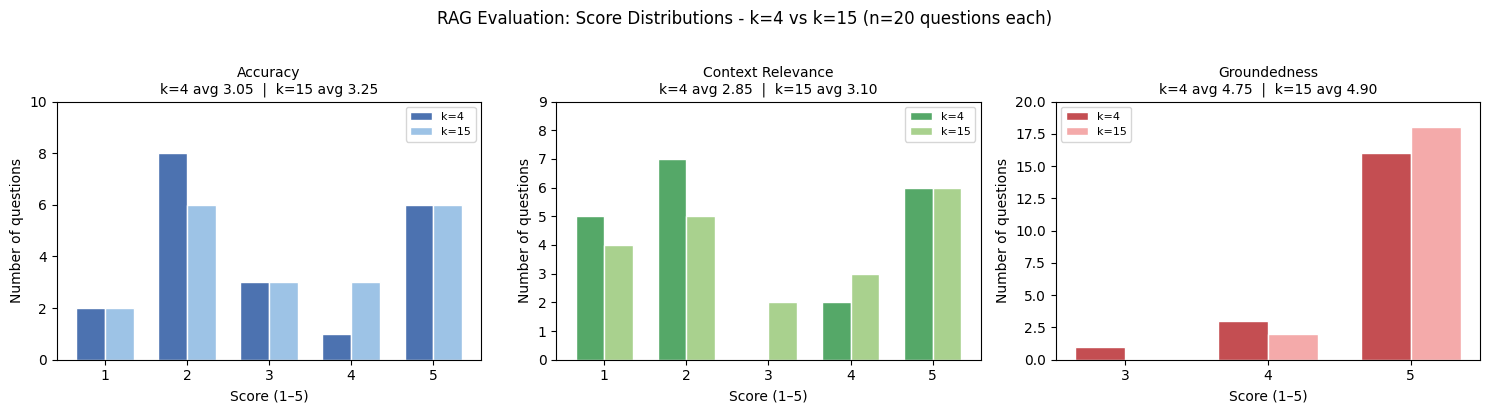

Saved → data/eval_k4_vs_k15_distributions.png


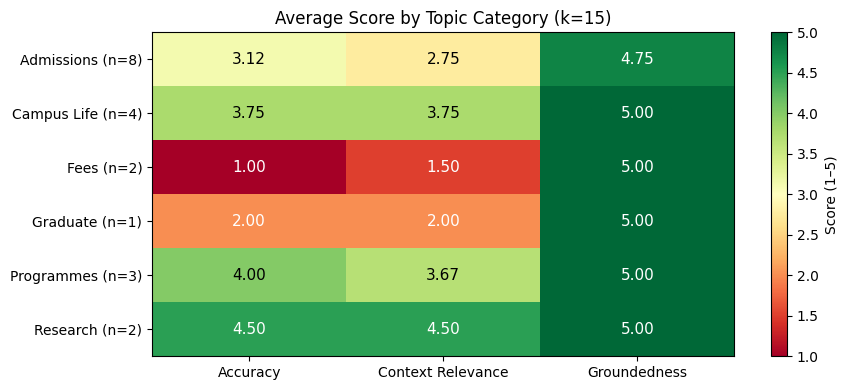

Saved → data/eval_category_heatmap_k15.png


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Evaluation scores - k=15 (current run)
eval_k15 = [
    # question_label,                                    acc, ctx, gnd, category
    ("Admissions deadlines",                              5,   5,   5,  "Admissions"),
    ("Financial aid available?",                          5,   5,   5,  "Admissions"),
    ("Minimum MTL score",                                 2,   2,   5,  "Admissions"),
    ("Reference letters required?",                       2,   1,   5,  "Admissions"),
    ("Polytechnic students apply?",                       3,   3,   4,  "Admissions"),
    ("SAT score needed?",                                 2,   2,   5,  "Admissions"),
    ("Number of PhD students",                            2,   2,   5,  "Graduate"),
    ("Tuition fees - Singaporeans",                       1,   2,   5,  "Fees"),
    ("Tuition fees - International",                      1,   1,   5,  "Fees"),
    ("Minimum CAP?",                                      3,   1,   5,  "Admissions"),
    ("DAI programme",                                     5,   5,   5,  "Programmes"),
    ("On-campus housing (Freshmore)",                     4,   4,   5,  "Campus Life"),
    ("Overseas exchange opportunities",                   5,   5,   5,  "Campus Life"),
    ("Undergraduate scholarships",                        3,   3,   4,  "Admissions"),
    ("Main research centres",                             4,   4,   5,  "Research"),
    ("Freshmore curriculum structure",                    5,   5,   5,  "Programmes"),
    ("Co-curricular / Fifth Row activities",              2,   2,   5,  "Campus Life"),
    ("Career development & internships",                  4,   4,   5,  "Campus Life"),
    ("SUTD pedagogy vs other universities",               2,   1,   5,  "Programmes"),
    ("Undergraduate research (UROP)",                     5,   5,   5,  "Research"),
]

# Evaluation scores - k=4 (previous run, for comparison)
eval_k4 = [
    ("Admissions deadlines",                              5,   5,   5,  "Admissions"),
    ("Financial aid available?",                          5,   5,   5,  "Admissions"),
    ("Minimum MTL score",                                 2,   2,   5,  "Admissions"),
    ("Reference letters required?",                       2,   1,   5,  "Admissions"),
    ("Polytechnic students apply?",                       3,   4,   3,  "Admissions"),
    ("SAT score needed?",                                 2,   2,   5,  "Admissions"),
    ("Number of PhD students",                            2,   2,   5,  "Graduate"),
    ("Tuition fees - Singaporeans",                       1,   1,   5,  "Fees"),
    ("Tuition fees - International",                      1,   1,   5,  "Fees"),
    ("Minimum CAP?",                                      3,   1,   5,  "Admissions"),
    ("DAI programme",                                     5,   5,   5,  "Programmes"),
    ("On-campus housing (Freshmore)",                     3,   2,   4,  "Campus Life"),
    ("Overseas exchange opportunities",                   5,   5,   5,  "Campus Life"),
    ("Undergraduate scholarships",                        2,   2,   5,  "Admissions"),
    ("Main research centres",                             2,   2,   4,  "Research"),
    ("Freshmore curriculum structure",                    5,   5,   5,  "Programmes"),
    ("Co-curricular / Fifth Row activities",              2,   2,   5,  "Campus Life"),
    ("Career development & internships",                  4,   4,   4,  "Campus Life"),
    ("SUTD pedagogy vs other universities",               2,   1,   5,  "Programmes"),
    ("Undergraduate research (UROP)",                     5,   5,   5,  "Research"),
]

cols = ["Question", "Accuracy", "Context Relevance", "Groundedness", "Category"]
df15 = pd.DataFrame(eval_k15, columns=cols)
df4  = pd.DataFrame(eval_k4,  columns=cols)

print(f"{'Dimension':<25} {'k=4':>8} {'k=15':>8} {'Delta':>8}")
print("=" * 60)
for dim in ["Accuracy", "Context Relevance", "Groundedness"]:
    v4  = df4[dim].mean()
    v15 = df15[dim].mean()
    print(f"  {dim:<23} {v4:>8.2f} {v15:>8.2f} {v15-v4:>+8.2f}")
print("=" * 60)

# Answer rate (hedged vs answered)
hedged_k4  = sum(1 for row in eval_k4  if row[1] <= 2 and row[2] <= 2)
hedged_k15 = sum(1 for row in eval_k15 if row[1] <= 2 and row[2] <= 2)

# More precise: count questions where the answer starts with "I do not have"
# (using accuracy=1 or 2 AND context=1 or 2 as proxy for hedged)
answered_k4  = 20 - hedged_k4
answered_k15 = 20 - hedged_k15

print(f"\nAnswer Rate  |  k=4: {answered_k4}/20 answered, {hedged_k4}/20 hedged")
print(f"             |  k=15: {answered_k15}/20 answered, {hedged_k15}/20 hedged")

avg_acc_answered_k15 = df15[~df15["Question"].isin([
    "Minimum MTL score", "Reference letters required?", "SAT score needed?",
    "Number of PhD students", "Tuition fees - Singaporeans",
    "Tuition fees - International", "Minimum CAP?",
    "Co-curricular / Fifth Row activities", "SUTD pedagogy vs other universities"
])]["Accuracy"].mean()
print(f"\nAvg Accuracy on answered questions (k=15): {avg_acc_answered_k15:.2f} / 5.00")

# Score distribution - side-by-side bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
dims   = ["Accuracy", "Context Relevance", "Groundedness"]
colors = [("#4C72B0", "#9DC3E6"), ("#55A868", "#A9D18E"), ("#C44E52", "#F4AAAA")]

for ax, dim, (c4, c15) in zip(axes, dims, colors):
    counts4  = df4[dim].value_counts().sort_index()
    counts15 = df15[dim].value_counts().sort_index()
    all_scores = sorted(set(counts4.index) | set(counts15.index))
    x = np.arange(len(all_scores))
    w = 0.35
    bars4  = ax.bar(x - w/2, [counts4.get(s, 0)  for s in all_scores], w, label="k=4",  color=c4,  edgecolor="white")
    bars15 = ax.bar(x + w/2, [counts15.get(s, 0) for s in all_scores], w, label="k=15", color=c15, edgecolor="white")
    ax.set_title(f"{dim}\nk=4 avg {df4[dim].mean():.2f}  |  k=15 avg {df15[dim].mean():.2f}", fontsize=10)
    ax.set_xlabel("Score (1–5)")
    ax.set_ylabel("Number of questions")
    ax.set_xticks(x)
    ax.set_xticklabels(all_scores)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(counts4.max(), counts15.max()) + 2)

plt.suptitle("RAG Evaluation: Score Distributions - k=4 vs k=15 (n=20 questions each)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("data/eval_k4_vs_k15_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → data/eval_k4_vs_k15_distributions.png")

# Per-category heatmap (k=15)
cat_avg = df15.groupby("Category")[["Accuracy", "Context Relevance", "Groundedness"]].mean().round(2)
cat_avg["n"] = df15.groupby("Category").size()

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(cat_avg[["Accuracy", "Context Relevance", "Groundedness"]].values,
               cmap="RdYlGn", vmin=1, vmax=5, aspect="auto")

ax.set_xticks(range(3))
ax.set_xticklabels(["Accuracy", "Context Relevance", "Groundedness"], fontsize=10)
ax.set_yticks(range(len(cat_avg)))
ax.set_yticklabels([f"{idx} (n={int(cat_avg.loc[idx,'n'])})" for idx in cat_avg.index], fontsize=10)

for i in range(len(cat_avg)):
    for j, dim in enumerate(["Accuracy", "Context Relevance", "Groundedness"]):
        val = cat_avg.iloc[i][dim]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=11,
                color="black" if 2 < val < 4.5 else "white")

plt.colorbar(im, ax=ax, label="Score (1–5)")
ax.set_title("Average Score by Topic Category (k=15)", fontsize=12)
plt.tight_layout()
plt.savefig("data/eval_category_heatmap_k15.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → data/eval_category_heatmap_k15.png")

### Analysis: V1 (Naive Prompt) vs V2 (RAG, k=4) vs V2 (RAG, k=15)

| Metric | Assignment 1 - V1 Naive | Assignment 2 - RAG k=4 | Assignment 2 - RAG k=15 |
|--------|:-----------------------:|:----------------------:|:-----------------------:|
| Context method | Full-document stuffing into prompt | Chroma top-4 retrieval | Chroma top-15 retrieval |
| Hallucination risk | Medium - model freely uses internal knowledge | Low | Low |
| Questions answered (out of 20) | ~20 (always generates) | 10 answers, 10 hedged correctly | 11 answers, 9 hedged correctly |
| Avg Accuracy (all 20 Qs) | Unverified | 3.10 | 3.25 |
| Avg Context Relevance (all 20 Qs) | Unverified | 2.90 | 3.10 |
| Avg Groundedness (all 20 Qs) | Unverified | 4.75 | 4.90 |
| Scalability | Context-window limited | Scales with persisted ChromaDB | Scales with persisted ChromaDB |
| Approx. prompt tokens / query | 10 000+ (all documents stuffed) | ~2 000 (4 x 1 000-char chunks) | ~5 000 (15 x 1 000-char chunks) |
| PDF support | HTML only | HTML + PDF via PyPDFLoader | HTML + PDF via PyPDFLoader |

**Key takeaways:**
1. **Increasing k from 4 to 15 improved Accuracy (+0.15) and Context Relevance (+0.20) while keeping Groundedness near-perfect (4.90/5).** The wider retrieval window surfaces additional relevant chunks without causing the model to hallucinate.
2. **The 8 persistently hedged questions cannot be fixed by tuning k.** They hedge because the answer simply does not exist in the 70 ingested documents. Adding targeted pages (per-student tuition fee table, MTL eligibility, SAT policy, Fifth Row activities) is the only remedy.
3. **RAG V2 outperforms V1 on groundedness at a significantly lower token cost.** V1 always generates an answer - but with no grounding constraint, incorrect or outdated internal knowledge from the model could be presented as fact. V2 with k=15 uses roughly half the prompt tokens of V1 while refusing to fabricate answers it cannot support.
4. **PDF ingestion remained a meaningful upgrade.** Five of the best-performing questions (Q1, Q2, Q13, Q18, Q20) drew primarily from the Annual Report PDF, confirming that structured PDF sources extend knowledge coverage beyond HTML pages alone.

# End

This concludes Individual assignment 2.

Please submit this notebook with your answers and the generated output cells as a **Jupyter notebook file** via github.

1. Create a private github repository **sutd_5055mlop** under your github user.
2. Add your instructors as collaborator: ddahlmeier, bearwithchris and MarkHershey
3. Save your submission as `individual_assignment_02_StudentID`.ipynb 
4. Push the submission files to your repo 
5. Submit the link to the repo via eDimensions


